In [2]:
import duckdb
import pandas as pd
import seaborn as sns
%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb


Tip: You may define configurations in /home/tiago/dev/uk-housing-affordability/pyproject.toml or /home/tiago/.jupysql/config.

Did not find user configurations in /home/tiago/dev/uk-housing-affordability/pyproject.toml.

In [3]:
%%sql
CREATE TABLE hpi AS FROM '../data/raw/UK-*.csv';

Running query in 'duckdb'

Count
149085


In [4]:
%%sql
CREATE TABLE average_earnings AS
SELECT 
    CAST(year AS INTEGER) AS year,
    CAST(retail_price_index AS DOUBLE) AS retail_price_index,
    CAST(average_annual_nominal_earnings AS DOUBLE) AS average_annual_nominal_earnings,
    CAST(average_annual_real_earnings AS DOUBLE) AS average_annual_real_earnings
FROM read_csv(
    '../data/raw/UKCPI_*.csv',
    nullstr = 'NA');

DESCRIBE average_earnings

Running query in 'duckdb'

column_name,column_type,null,key,default,extra
year,INTEGER,YES,None,None,None
retail_price_index,DOUBLE,YES,None,None,None
average_annual_nominal_earnings,DOUBLE,YES,None,None,None
average_annual_real_earnings,DOUBLE,YES,None,None,None


In [5]:
conn.sql("DESCRIBE hpi").show(max_rows=100)

┌────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │ column_type │  null   │   key   │ default │  extra  │
│        varchar         │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Date                   │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ RegionName             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AreaCode               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AveragePrice           │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Index                  │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ IndexSA                │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ 1m%Change              │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ 12m%Change             │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ AveragePriceSA         │ V

In [6]:
%%sql 
SELECT MIN(Date), MAX(Date) FROM hpi

Running query in 'duckdb'

min(Date),max(Date)
1968-04-01,2025-12-01


In [7]:
conn.sql("""
        SELECT DISTINCT RegionName, AreaCode 
        FROM hpi
        ORDER BY RegionName    
        """).show(max_rows=500)

┌─────────────────────────────────────┬───────────┐
│             RegionName              │ AreaCode  │
│               varchar               │  varchar  │
├─────────────────────────────────────┼───────────┤
│ Aberdeenshire                       │ S12000034 │
│ Adur                                │ E07000223 │
│ Amber Valley                        │ E07000032 │
│ Angus                               │ S12000041 │
│ Antrim and Newtownabbey             │ N09000001 │
│ Ards and North Down                 │ N09000011 │
│ Argyll and Bute                     │ S12000035 │
│ Armagh City Banbridge and Craigavon │ N09000002 │
│ Arun                                │ E07000224 │
│ Ashfield                            │ E07000170 │
│ Ashford                             │ E07000105 │
│ Babergh                             │ E07000200 │
│ Barking and Dagenham                │ E09000002 │
│ Barnet                              │ E09000003 │
│ Barnsley                            │ E08000038 │
│ Basildon  

In [ ]:
avg_prices_per_date = conn.sql(""" 
         SELECT 
            Date,
            AveragePrice,
            DetachedPrice,
            SemiDetachedPrice,
            TerracedPrice,
            FlatPrice
         FROM hpi
         WHERE RegionName = 'United Kingdom'
         """)
avg_prices_per_date

┌────────────┬──────────────┬───────────────┬───────────────────┬───────────────┬───────────┐
│    Date    │ AveragePrice │ DetachedPrice │ SemiDetachedPrice │ TerracedPrice │ FlatPrice │
│    date    │    int64     │     int64     │       int64       │     int64     │   int64   │
├────────────┼──────────────┼───────────────┼───────────────────┼───────────────┼───────────┤
│ 1968-04-01 │         3311 │          NULL │              NULL │          NULL │      NULL │
│ 1968-05-01 │         3311 │          NULL │              NULL │          NULL │      NULL │
│ 1968-06-01 │         3311 │          NULL │              NULL │          NULL │      NULL │
│ 1968-07-01 │         3424 │          NULL │              NULL │          NULL │      NULL │
│ 1968-08-01 │         3424 │          NULL │              NULL │          NULL │      NULL │
│ 1968-09-01 │         3424 │          NULL │              NULL │          NULL │      NULL │
│ 1968-10-01 │         3405 │          NULL │              N

Text(0.5, 1.0, 'Average House Price (1968-2025)')

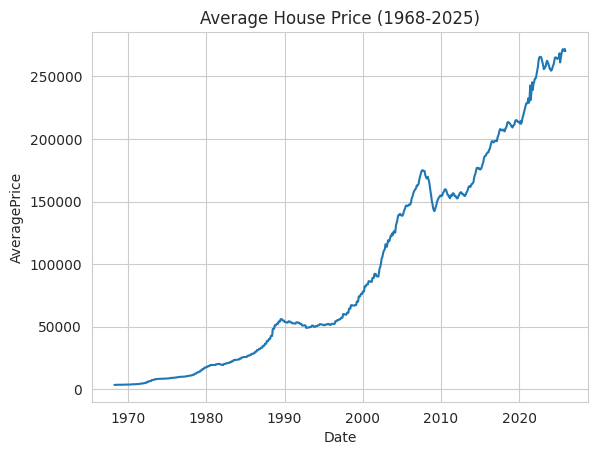

In [9]:
## Average house prices since 1968
sns.set_style("whitegrid")
sns.lineplot(data=avg_prices_per_date.to_df(), x="Date", y="AveragePrice").set_title("Average House Price (1968-2025)")

Text(0.5, 1.0, 'Average Price per House Type (2005-2025)')

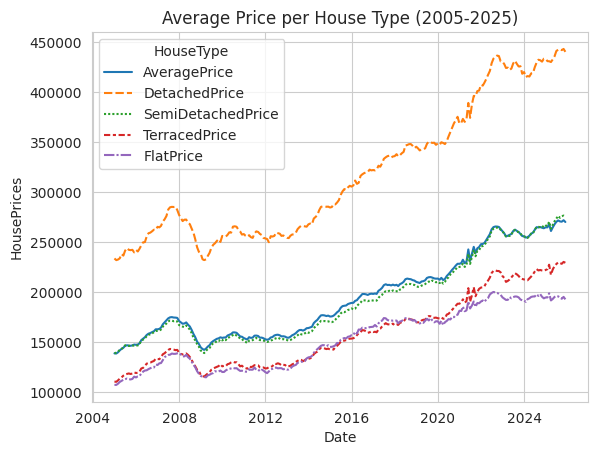

In [10]:
## Average house prices per house type since 2005
avg_prices_per_date_non_null = conn.sql(""" 
         FROM avg_prices_per_date
         WHERE DetachedPrice IS NOT NULL                               
         """).to_df()

avg_prices_per_date_non_null = pd.melt(avg_prices_per_date_non_null, id_vars='Date', 
                                       value_vars=["AveragePrice","DetachedPrice", "SemiDetachedPrice", "TerracedPrice", "FlatPrice"], 
                                       value_name='HousePrices', 
                                       var_name='HouseType')

sns.lineplot(data=avg_prices_per_date_non_null, x="Date", y="HousePrices",hue="HouseType", style="HouseType").set_title("Average Price per House Type (2005-2025)")

In [11]:
## Top 10 most expensive Areas currently
conn.sql("""
SELECT DISTINCT RegionName, AreaCode, AveragePrice
FROM hpi
WHERE Date = '2025-12-01'
ORDER BY AveragePrice DESC
LIMIT 10
         """).show(max_rows=10)

┌────────────────────────┬───────────┬──────────────┐
│       RegionName       │ AreaCode  │ AveragePrice │
│        varchar         │  varchar  │    int64     │
├────────────────────────┼───────────┼──────────────┤
│ Kensington and Chelsea │ E09000020 │      1178497 │
│ City of Westminster    │ E09000033 │       880389 │
│ Camden                 │ E09000007 │       783812 │
│ Richmond upon Thames   │ E09000027 │       777164 │
│ Elmbridge              │ E07000207 │       743009 │
│ City of London         │ E09000001 │       740433 │
│ Hammersmith and Fulham │ E09000013 │       713773 │
│ Islington              │ E09000019 │       699726 │
│ Wandsworth             │ E09000032 │       689285 │
│ Inner London           │ E13000001 │       628142 │
└────────────────────────┴───────────┴──────────────┘
  10 rows                                 3 columns



In [12]:
## Top 10 least expensive Areas currently
conn.sql("""
SELECT DISTINCT RegionName, AreaCode, AveragePrice
FROM hpi
WHERE Date = '2025-12-01'
ORDER BY AveragePrice ASC
LIMIT 10
         """).show(max_rows=10)

┌────────────────────────────┬───────────┬──────────────┐
│         RegionName         │ AreaCode  │ AveragePrice │
│          varchar           │  varchar  │    int64     │
├────────────────────────────┼───────────┼──────────────┤
│ Inverclyde                 │ S12000018 │       113267 │
│ East Ayrshire              │ S12000008 │       131065 │
│ West Dunbartonshire        │ S12000039 │       131097 │
│ City of Kingston upon Hull │ E06000010 │       131323 │
│ Burnley                    │ E07000117 │       131476 │
│ Hartlepool                 │ E06000001 │       132463 │
│ City of Aberdeen           │ S12000033 │       133119 │
│ North Ayrshire             │ S12000021 │       134830 │
│ Hyndburn                   │ E07000120 │       135525 │
│ Blackpool                  │ E06000009 │       136485 │
└────────────────────────────┴───────────┴──────────────┘
  10 rows                                     3 columns



Text(0.5, 1.0, 'Average House Price per country in UK (1968-2025)')

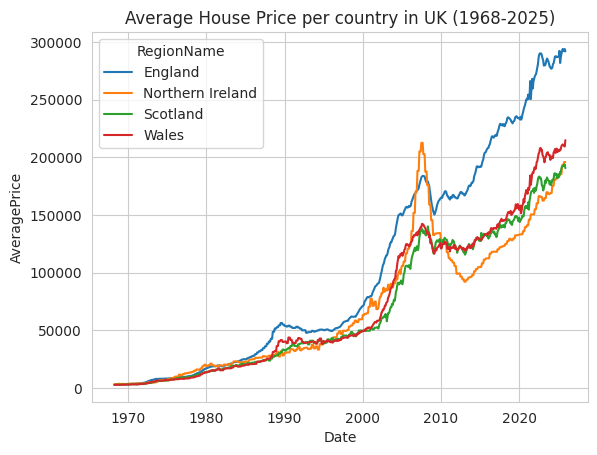

In [13]:
## Average House Price per country in UK (1968-2025)
avg_prices_per_country = conn.sql("""
        SELECT Date, RegionName, AreaCode, AveragePrice
        FROM hpi
        WHERE RegionName in ('England', 'Wales', 'Scotland', 'Northern Ireland')
        """).to_df()


sns.lineplot(data=avg_prices_per_country, x="Date", y="AveragePrice",hue="RegionName",).set_title("Average House Price per country in UK (1968-2025)")

In [14]:
%%sql
DESCRIBE average_earnings

Running query in 'duckdb'

column_name,column_type,null,key,default,extra
year,INTEGER,YES,None,None,None
retail_price_index,DOUBLE,YES,None,None,None
average_annual_nominal_earnings,DOUBLE,YES,None,None,None
average_annual_real_earnings,DOUBLE,YES,None,None,None


In [22]:
average_earnings_ratio = conn.sql("""
        SELECT 
                year, 
                average_annual_nominal_earnings,
                average_annual_nominal_earnings / FIRST_VALUE(average_annual_nominal_earnings) 
                        OVER(ORDER BY year) avg_earnings_ratio_to_1969
        FROM average_earnings
        WHERE year >= 1969
        """).to_df()
average_earnings_ratio[:3]

,year,average_annual_nominal_earnings,avg_earnings_ratio_to_1969
0,1969,962.35,1.000000
1,1970,1079.54,1.121775
2,1971,1202.25,1.249286


In [ ]:
## TODO: do the same ration for average house prices per year and compare them in a plot
average_house_price_ratio = conn.sql("""
        SELECT 
                Year(Date) AS year,
                AveragePrice,
                AveragePrice / FIRST_VALUE(AveragePrice) 
                OVER(ORDER BY year) avg_house_price_ratio_to_1969
        FROM hpi
        WHERE MONTH(DATE) == 1
                AND RegionName = 'England'
        ORDER BY DATE
                                     
        """).to_df()
average_house_price_ratio[:3]

,year,AveragePrice,avg_house_price_ratio_to_1969
0,1969,3364,1.000000
1,1970,3510,1.043401
2,1971,3839,1.141201


<Axes: xlabel='year', ylabel='avg_house_price_ratio_to_1969'>

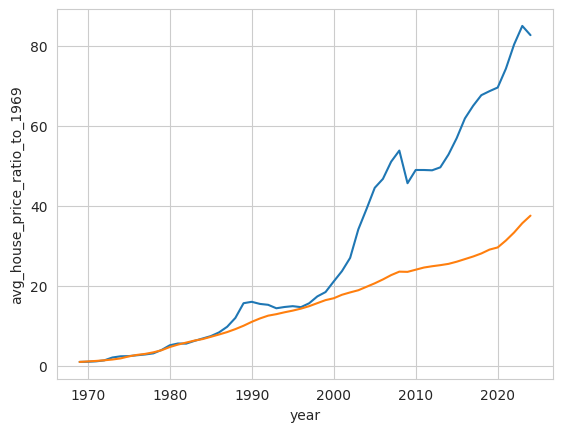

In [40]:
price_and_earning_ratios = conn.sql("""
         SELECT 
            ahp.year,
            ahp.avg_house_price_ratio_to_1969,
            ae.avg_earnings_ratio_to_1969
         FROM average_house_price_ratio ahp
         JOIN average_earnings_ratio ae ON ahp.year = ae.year
         """).to_df()

price_and_earning_ratios
sns.lineplot(data=price_and_earning_ratios, x="year", y="avg_house_price_ratio_to_1969")
sns.lineplot(data=price_and_earning_ratios, x="year", y="avg_earnings_ratio_to_1969")